In [1]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import os
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

/Users/digvijaysinhajarekar/Study/CCKA-Clustered_Centroid_Kernel_Alignment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/digvijaysinhajarekar/Study/CCKA-Clustered_Centroid_Kernel_Alignment/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    x_test = jnp.asarray(data['x_test'])
    y_test = jnp.asarray(data['y_test'])

    X_combined = jnp.concatenate([X, x_test], axis=0)
    y_combined = jnp.concatenate([y, y_test], axis=0)

    return X_combined, y_combined

X, y = load_data('../data/corners.npy')
X.shape

(200, 2)

In [3]:
kernel_noisy = quackEmbeddingCircuit(
                                num_qubits = 5,
                                reps = 10,
                                reupload = True,
                                noisy=True,
                                noise_type='coherent',
                                noise_level=0.9,
                                seed=42
                        )
init_weights_noisy = kernel_noisy.init_weights()
model_noisy = KernelModel(circuit = kernel_noisy, device_name= 'default.mixed', diff_method=None)

In [4]:
kernel = quackEmbeddingCircuit(
                                num_qubits = 5,
                                reps = 10,
                                reupload = True,
                                noisy=False,
                                seed=42
                        )
init_weights = kernel.init_weights()
model = KernelModel(circuit = kernel, device_name= 'default.qubit', diff_method='backprop')

In [5]:
# ── kernel heatmap comparison panel ────────────────────────────────────────

def plot_kernel_comparison(
    kernel_noiseless,
    kernel_noisy,
    dataset_name: str = '',
    figsize=(13, 5),
):
    """
    Plot two kernel matrices side by side as heatmaps:
    left panel = noiseless kernel, right panel = noisy kernel.

    Both heatmap axes are forced to be exactly square.
    A shared diverging colourbar is placed on the far right so both
    heatmaps are directly comparable on the same scale.

    Parameters
    ----------
    kernel_noiseless : array-like, shape (N, N)
        Kernel matrix computed without noise.
    kernel_noisy : array-like, shape (N, N)
        Kernel matrix computed with depolarising noise.
    dataset_name : str
        Optional dataset label appended to the figure suptitle.
    figsize : tuple
        Overall figure size in inches.
    """
    K_clean = np.asarray(kernel_noiseless)
    K_noisy = np.asarray(kernel_noisy)

    # ── shared colour scale across both panels ────────────────────────────
    vmin = min(K_clean.min(), K_noisy.min())
    vmax = max(K_clean.max(), K_noisy.max())

    kernels = [K_clean, K_noisy]
    titles  = ['Noiseless Kernel', 'Noisy Kernel']

    # ── figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        facecolor='white',
    )

    suffix = f' — {dataset_name}' if dataset_name else ''
    fig.suptitle(
        f'Kernel Matrix Comparison{suffix}',
        fontsize=13, fontweight='bold', y=1.02,
    )

    im = None
    for col, (ax, K, title) in enumerate(zip(axes, kernels, titles)):
        im = ax.imshow(
            K,
            cmap='RdBu_r',
            aspect='equal',         # pixels are square
            vmin=vmin,
            vmax=vmax,
            interpolation='nearest',
        )

        # Force the axes bounding box itself to be square
        ax.set_box_aspect(1)

        ax.set_title(title, fontsize=12, fontweight='bold')
        #ax.set_xlabel('Sample Index', fontsize=12)
        #ax.set_ylabel('Sample Index', fontsize=12)

        # Tick density: at most 10 ticks on each axis
        #n = K.shape[0]
        #step = max(1, n // 10)
        #ticks = list(range(0, n, step))
        #ax.set_xticks(ticks)
        #ax.set_yticks(ticks)
        #ax.set_xticklabels(ticks, fontsize=10)
        #ax.set_yticklabels(ticks, fontsize=10)

        ax.spines[['top', 'right']].set_visible(False)

    # ── shared colourbar on the right ─────────────────────────────────────
    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation='vertical',
        fraction=0.03,
        pad= -0.2,
        shrink=0.85,
    )
    cbar.set_label('Kernel Value', fontsize=11)
    #cbar.ax.tick_params(labelsize=10)

    fig.tight_layout()

    for fmt in ('png', 'pdf'):
        fig.savefig(
            f'kernel_comparison.{fmt}',
            dpi=1200, bbox_inches='tight', facecolor='white',
        )
    plt.show()
    print("Saved: kernel_comparison.png  /  kernel_comparison.pdf")

In [6]:
def kernel_similarity(K, L, method: str = 'cka', center: bool = True):
    """
    Compute the similarity between two kernel matrices.

    Three methods are available:

    'cka'  – Centered Kernel Alignment (recommended).
              Measures how similar the geometry induced by K is to that of L.
              Invariant to isotropic scaling and orthogonal transformations.
              Returns 1.0 for identical kernels, 0.0 for orthogonal kernels.
              Ref: Kornblith et al., ICML 2019.

    'fro'  – Normalised Frobenius similarity.
              Element-wise distance turned into a [0, 1] similarity score.
              Simple and fast; sensitive to absolute value differences.
              Returns 1.0 for identical kernels, approaches 0 for very
              different kernels.

    'spectral' – Spectral similarity.
              Compares the eigenvalue spectra of the two kernels via cosine
              similarity of their sorted eigenvalue vectors.
              Captures structural / rank differences that element-wise
              metrics can miss.
              Returns 1.0 for identical spectra, -1.0 for opposite spectra.

    Parameters
    ----------
    K, L   : array-like, shape (N, N)
        Two square kernel matrices of the same size.
    method : str
        One of 'cka', 'fro', 'spectral'.
    center : bool
        If True, apply centering (H @ K @ H) before computing similarity.
        Recommended for 'cka'; has no effect for 'spectral'.

    Returns
    -------
    similarity : float
        Scalar similarity value.
    """
    K = jnp.array(K, dtype=jnp.float32)
    L = jnp.array(L, dtype=jnp.float32)

    assert K.shape == L.shape,       "Kernels must have the same shape"
    assert K.shape[0] == K.shape[1], "Kernels must be square"

    # ── optional centering ────────────────────────────────────────────────
    def _center(M):
        n = M.shape[0]
        H = jnp.eye(n) - jnp.ones((n, n)) / n
        return H @ M @ H

    if center:
        K = _center(K)
        L = _center(L)

    # ── similarity methods ────────────────────────────────────────────────
    if method == 'cka':
        # HSIC(K, L) / sqrt(HSIC(K, K) * HSIC(L, L))
        # With pre-centered matrices HSIC reduces to <K, L>_F
        numerator = jnp.sum(K * L)
        denom     = jnp.sqrt(jnp.sum(K * K) * jnp.sum(L * L))
        return float(numerator / (denom + 1e-10))

    elif method == 'fro':
        # 1 - normalised Frobenius distance
        diff      = jnp.linalg.norm(K - L, ord='fro')
        scale     = jnp.linalg.norm(K, ord='fro') + jnp.linalg.norm(L, ord='fro')
        return float(1.0 - diff / (scale + 1e-10))

    elif method == 'spectral':
        # Cosine similarity of sorted eigenvalue vectors
        # centering is not meaningful for eigenspectra so use originals
        eigK = jnp.sort(jnp.linalg.eigvalsh(K))[::-1]
        eigL = jnp.sort(jnp.linalg.eigvalsh(L))[::-1]
        numerator = jnp.dot(eigK, eigL)
        denom     = (jnp.linalg.norm(eigK) * jnp.linalg.norm(eigL))
        return float(numerator / (denom + 1e-10))

    else:
        raise ValueError(f"Unknown method '{method}'. Choose from: 'cka', 'fro', 'spectral'.")

In [7]:
# ── kernel similarity metrics panel ────────────────────────────────────────

_SIMILARITY_STYLES = {
    'cka':       {'color': '#4477AA', 'marker': 'o', 'linestyle': '-',  'label': 'CKA'},
    'spectral':  {'color': '#EE6677', 'marker': 's', 'linestyle': '--', 'label': 'Spectral'},
    'frobenius': {'color': '#228833', 'marker': '^', 'linestyle': ':',  'label': 'Frobenius'},
}


def plot_similarity_metrics(
    alignment_similarity,
    spectral_similarity,
    frobenius_similarity,
    x_values=None,
    x_label: str = 'Noise Level',
    dataset_name: str = '',
    figsize=(8, 5),
):
    """
    Plot CKA, Spectral, and Frobenius similarity metrics as three lines
    on a single axes, so trends across metrics can be compared directly.

    Parameters
    ----------
    alignment_similarity  : list[float]
        CKA similarity values, one per x_value.
    spectral_similarity   : list[float]
        Spectral similarity values, one per x_value.
    frobenius_similarity  : list[float]
        Frobenius similarity values, one per x_value.
    x_values : list | None
        X-axis tick values (e.g. noise levels [0.01, 0.05, 0.1, ...]).
        Defaults to [0, 1, 2, ...] if None.
    x_label : str
        X-axis label.
    dataset_name : str
        Optional dataset label appended to the figure title.
    figsize : tuple
        Overall figure size in inches.
    """
    metrics = {
        'cka':       np.asarray(alignment_similarity),
        'spectral':  np.asarray(spectral_similarity),
        'frobenius': np.asarray(frobenius_similarity),
    }

    n_points = len(next(iter(metrics.values())))
    xs = np.asarray(x_values) if x_values is not None else np.arange(n_points)

    assert all(len(v) == n_points for v in metrics.values()), \
        "All three similarity lists must have the same length."

    # ── figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')

    suffix = f' — {dataset_name}' if dataset_name else ''
    ax.set_title(
        f'Noisy vs. Noiseless Kernel Similarity{suffix}',
        fontsize=13, fontweight='bold',
    )

    for key, vals in metrics.items():
        sty = _SIMILARITY_STYLES[key]
        ax.plot(
            xs, vals,
            color=sty['color'],
            marker=sty['marker'],
            linestyle=sty['linestyle'],
            linewidth=1.8,
            markersize=6,
            alpha=0.9,
            markerfacecolor='white',
            markeredgewidth=1.5,
            label=sty['label'],
        )

    # ── reference line at 1.0 (perfect similarity) ────────────────────────
    ax.axhline(
        1.0,
        color='#aaaaaa',
        linestyle='--',
        linewidth=0.9,
        alpha=0.7,
        label='Perfect similarity',
    )

    # ── axes formatting ───────────────────────────────────────────────────
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Similarity', fontsize=12)

    ax.set_xticks(xs)
    ax.set_xticklabels(
        [f'{v:.2g}' for v in xs],
        fontsize=10, rotation=45, ha='right',
    )

    all_vals = np.concatenate(list(metrics.values()))
    y_lo = min(all_vals.min(), 0.0)
    y_hi = max(all_vals.max(), 1.0)
    pad  = (y_hi - y_lo) * 0.05 or 0.05
    ax.set_ylim(y_lo - pad, y_hi + pad)

    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=2)
    ax.tick_params(axis='both', labelsize=10)

    ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=10,
        loc='lower left',
        framealpha=0.85,
        edgecolor='#cccccc',
        frameon=True,
        title='Metric',
        title_fontsize=10,
    )

    fig.tight_layout()

    for fmt in ('png', 'pdf'):
        fig.savefig(
            f'kernel_similarity_metrics.{fmt}',
            dpi=1200, bbox_inches='tight', facecolor='white',
        )
    plt.show()
    print("Saved: kernel_similarity_metrics.png  /  kernel_similarity_metrics.pdf")

In [8]:
x1 = jnp.repeat(X, X.shape[0], axis=0)
x2 = jnp.tile(X, (X.shape[0], 1))

print("Computing noisy kernel matrix...")
print("Noisy kernel matrix shape:", (X.shape[0], X.shape[0]))
knoisy = model_noisy.forward(x1, x2, weights= init_weights_noisy).reshape(X.shape[0], X.shape[0])
print("Noisy kernel matrix computed.")

print("Computing normal kernel matrix...")
print("Normal kernel matrix shape:", (X.shape[0], X.shape[0]))
knormal = model.forward(x1, x2, weights= init_weights).reshape(X.shape[0], X.shape[0])
print("Normal kernel matrix computed.")

Computing noisy kernel matrix...
Noisy kernel matrix shape: (200, 200)


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[150].
The error occurred while tracing the function kernel_circuit at /Users/digvijaysinhajarekar/Study/CCKA-Clustered_Centroid_Kernel_Alignment/ccka/circuits/angleEmbeddingKernel.py:105 for jit. This concrete value was not available in Python because it depends on the value of the argument weights.
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [ ]:
print("Noisy kernel stats:")
print("min:", knoisy.min(), "max:", knoisy.max(), "std:", knoisy.std())

print("Noiseless kernel stats:")
print("min:", knormal.min(), "max:", knormal.max(), "std:", knormal.std())

Noisy kernel stats:
min: 6.763257e-07 max: 0.9999974 std: 0.1580772
Noiseless kernel stats:
min: 4.963533e-06 max: 0.99999774 std: 0.17874555


In [ ]:
alignment = kernel_similarity(knoisy, knormal, method='cka', center=True)
print(f"Kernel Alignment (centered): {alignment:.4f}")

Kernel Alignment (centered): 0.9174


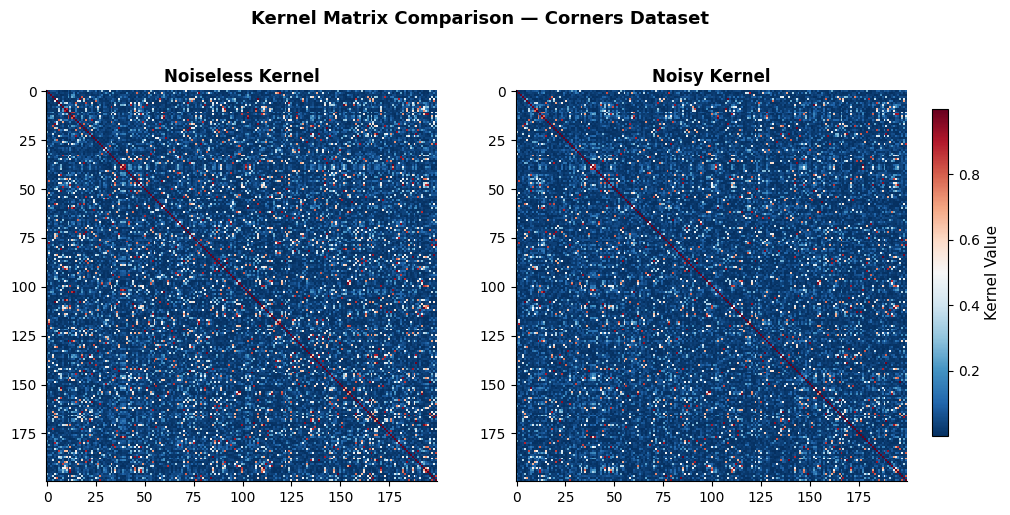

Saved: kernel_comparison.png  /  kernel_comparison.pdf


In [ ]:
plot_kernel_comparison(
    kernel_noiseless=knormal,
    kernel_noisy=knoisy,
    dataset_name='Corners Dataset',
    figsize=(12, 5),
)

In [ ]:
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

alignment_similarity = []
spectral_similarity = []
frobenius_similarity = []
for noise in noise_levels:
    print(f"\n=== Noise Level: {noise:.1f} ===")
    kernel_noisy = quackEmbeddingCircuit(
                                num_qubits = 2,
                                reps = 3,
                                reupload = True,
                                noisy=True,
                                noise_type='coherent',
                                noise_level=noise
                        )
    init_weights = kernel_noisy.init_weights()
    model_noisy = KernelModel(circuit = kernel_noisy, device_name= 'default.mixed', diff_method=None)

    knoisy = model_noisy.forward(x1, x2, weights= init_weights).reshape(X.shape[0], X.shape[0])
    alignment_similarity.append(kernel_similarity(knoisy, knormal, method='cka', center=True))
    spectral_similarity.append(kernel_similarity(knoisy, knormal, method='spectral', center=True))
    frobenius_similarity.append(kernel_similarity(knoisy, knormal, method='fro', center=True))



=== Noise Level: 0.0 ===

=== Noise Level: 0.1 ===

=== Noise Level: 0.2 ===

=== Noise Level: 0.3 ===

=== Noise Level: 0.5 ===

=== Noise Level: 0.6 ===

=== Noise Level: 0.7 ===

=== Noise Level: 0.8 ===

=== Noise Level: 0.9 ===

=== Noise Level: 1.0 ===


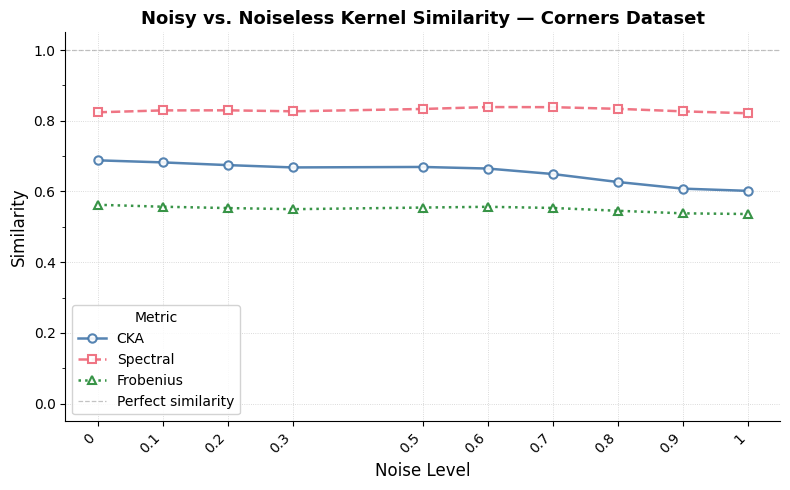

Saved: kernel_similarity_metrics.png  /  kernel_similarity_metrics.pdf


In [ ]:
plot_similarity_metrics(
    alignment_similarity  = alignment_similarity,
    spectral_similarity   = spectral_similarity,
    frobenius_similarity  = frobenius_similarity,
    x_values              = noise_levels,
    x_label               = 'Noise Level',
    dataset_name          = 'Corners Dataset',
)